# Cancer Mutation Classification - Modular Analysis


In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

sys.path.append(os.path.abspath('..'))

from src.data_loader import load_clean_data
from src.features import FeatureEngineer
from src.training import train_pipeline
from src.evaluation import evaluate_medical_utility, plot_visual_assessment
from src.config import RANDOM_STATE, TEST_SIZE


I0000 00:00:1776622211.716551   40418 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776622211.717800   40418 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776622211.760897   40418 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776622213.110399   40418 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

## 1. Data Procurement
Loading high-confidence variants (2-4 stars) from the ClinVar summary.

In [2]:
df = load_clean_data(row_limit=1000000)

train_df, test_df = train_test_split(
    df, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE, 
    stratify=df['ClinSigSimple']
)

print(f"Training set: {len(train_df)} variants")
print(f"Test set: {len(test_df)} variants")

Dataset successfully loaded. Final size: 674256 variants.
Training set: 573117 variants
Test set: 101139 variants


## 2. Feature Engineering & Preparation
Extracting biological features (Ti/Tv ratio) and gene-level statistics.

In [3]:
engineer = FeatureEngineer()
X_train = engineer.fit_transform(train_df)
X_test = engineer.transform(test_df)

y_train = train_df['ClinSigSimple'].values
y_test = test_df['ClinSigSimple'].values

## 3. Neural Architecture & Training
The model utilizes a Focal Loss function to maintain high detection rates for rare pathogenic variants.

In [4]:
model, history = train_pipeline(X_train, y_train, engineer)

Epoch 1/100


E0000 00:00:1776622257.131935   40418 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1776622257.132678   40499 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1776622257.145428   40418 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


238/238 ━━━━━━━━━━━━━━━━━━━━ 21s 80ms/step - accuracy: 0.8880 - loss: 0.0381 - precision: 0.6780 - recall: 0.4314 - val_accuracy: 0.8785 - val_loss: 0.0418 - val_precision: 0.9177 - val_recall: 0.1557 - learning_rate: 0.0010
Epoch 2/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 17s 71ms/step - accuracy: 0.8987 - loss: 0.0344 - precision: 0.7362 - recall: 0.4685 - val_accuracy: 0.9028 - val_loss: 0.0354 - val_precision: 0.7693 - val_recall: 0.4477 - learning_rate: 0.0010
Epoch 3/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 14s 58ms/step - accuracy: 0.9004 - loss: 0.0336 - precision: 0.7421 - recall: 0.4785 - val_accuracy: 0.9021 - val_loss: 0.0335 - val_precision: 0.7083 - val_recall: 0.5247 - learning_rate: 0.0010
Epoch 4/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - accuracy: 0.9020 - loss: 0.0328 - precision: 0.7463 - recall: 0.4900 - val_accuracy: 0.9047 - val_loss: 0.0332 - val_precision: 0.7407 - val_recall: 0.5026 - learning_rate: 0.0010
Epoch 5/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - accurac

## 4. Medical Utility Assessment

3161/3161 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step

--- Clinical Performance Appraisal (Threshold: 0.3048) ---
              precision    recall  f1-score   support

           0       0.97      0.75      0.84     86539
           1       0.36      0.85      0.51     14600

    accuracy                           0.76    101139
   macro avg       0.66      0.80      0.67    101139
weighted avg       0.88      0.76      0.79    101139



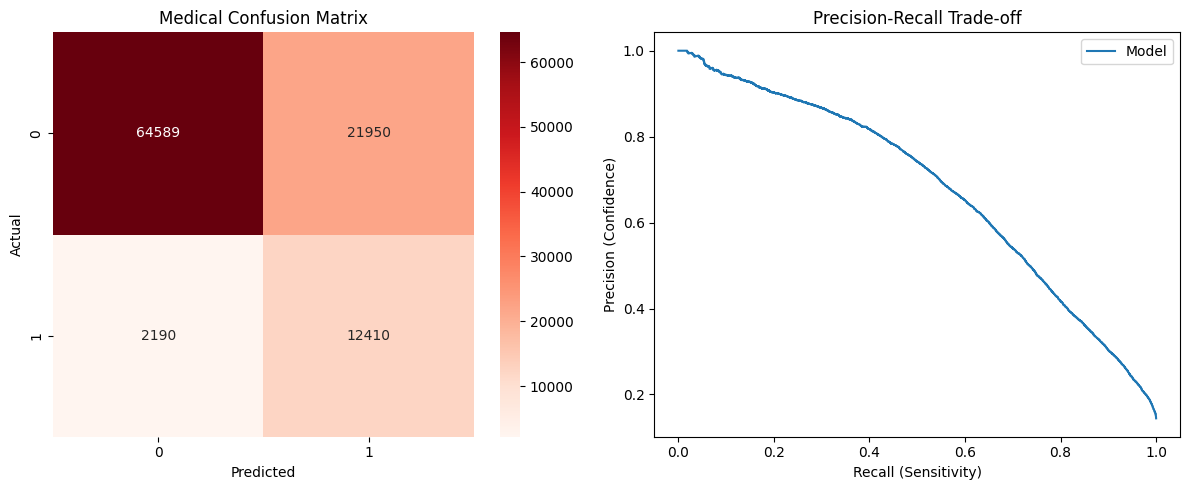

In [5]:
y_pred, y_probs, threshold = evaluate_medical_utility(model, X_test, y_test)
plot_visual_assessment(y_test, y_pred, y_probs)